# Bank Ranking — Lead / Customer Prioritization

## Business Case

A bank may have thousands of leads but limited sales capacity.

The business question is:

> **Which leads should the sales team contact first?**

This is a **ranking problem**.

Instead of simply predicting:

```text
Will customer convert?
Yes / No
```

we estimate a score and then rank:

```text
Lead A → 0.82
Lead B → 0.77
Lead C → 0.65
...
```

The sales team can focus on the highest-priority leads.

> This notebook uses synthetic banking data for education.

## 1. Ranking vs Classification

### Classification

Question:

> Will this lead convert?

Output:

```text
0 / 1
```

or:

```text
Probability = 0.72
```

### Ranking

Question:

> Which leads should be contacted first?

Output:

```text
Rank 1
Rank 2
Rank 3
...
```

The distinction matters because a sales team may only have capacity to contact the top 100 leads.

## 2. Banking Use Cases

Ranking can be applied to:

- Sales lead prioritization
- Credit card acquisition
- Personal loan leads
- Mortgage leads
- Wealth-management prospects
- Collection prioritization
- Retention intervention
- Branch appointment prioritization
- Customer service escalation

The ranking objective should match the business objective.

## 3. Ranking Pipeline

```text
Customer / Lead Data
        ↓
Feature Engineering
        ↓
Prediction Model
        ↓
Customer Score
        ↓
Ranking
        ↓
Top-N Selection
        ↓
Sales / CRM Action
        ↓
Outcome
        ↓
Ranking Evaluation
```

## 4. Import Libraries

This step imports the libraries used throughout the notebook — pandas and NumPy for data handling, scikit-learn for the conversion model and metrics, and Matplotlib/Seaborn for visualisation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns",100)

df=pd.read_csv("bank_lead_prioritization_sample.csv")

print("Rows:",len(df))
display(df.head())
# --- Save all outputs to the local output/ folder ---
from pathlib import Path

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)


def save_plot(filename, dpi=150):
    """Save the current matplotlib figure into the output/ folder."""
    path = OUTPUT_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {path}")


Rows: 4000


,Lead_ID,Age,Monthly_Income,Account_Tenure_Months,Product_Count,Monthly_Transactions,Digital_Engagement,Balance,Credit_Utilization,Recent_Application,Segment,Converted,Conversion_Probability
0,L00001,25,18604537,44,1,23,52,2.721934e+07,0.234540,0,Mass,0,0.135760
1,L00002,55,42765670,111,5,18,21,3.144224e+06,0.849369,0,Mass,1,0.294055
2,L00003,50,5622935,52,2,16,54,2.038614e+07,0.067987,0,Mass,0,0.094942
3,L00004,40,24533916,48,4,23,18,2.201551e+07,0.842110,1,Mass,0,0.134547
4,L00005,40,40844195,180,5,22,95,1.538804e+07,0.087282,0,Mass,1,0.509052


## 5. Dataset Dictionary

Every lead attribute is defined — segment, income, engagement, prior products and the conversion outcome. This fixes which features are legitimately known before a call is made, the key to avoiding leakage in ranking.


In [2]:
dictionary=pd.DataFrame({
    "Column":[
        "Lead_ID","Age","Monthly_Income",
        "Account_Tenure_Months","Product_Count",
        "Monthly_Transactions","Digital_Engagement",
        "Balance","Credit_Utilization",
        "Recent_Application","Segment","Converted"
    ],
    "Meaning":[
        "Lead identifier","Customer age","Monthly income",
        "Bank relationship duration","Number of products",
        "Monthly transaction count","Digital engagement score",
        "Approximate account balance","Credit utilization",
        "Recent application indicator","Customer segment",
        "Historical conversion outcome"
    ]
})
display(dictionary)

,Column,Meaning
0,Lead_ID,Lead identifier
1,Age,Customer age
2,Monthly_Income,Monthly income
3,Account_Tenure_Months,Bank relationship duration
4,Product_Count,Number of products
5,Monthly_Transactions,Monthly transaction count
6,Digital_Engagement,Digital engagement score
7,Balance,Approximate account balance
8,Credit_Utilization,Credit utilization
9,Recent_Application,Recent application indicator


## 6. Explore Conversion

Conversion rates are compared across segments and key attributes. This shows where the real signal lives and what a random calling order would achieve as a baseline.


In [3]:
display(
    df.groupby("Segment")["Converted"]
      .agg(["count","mean"])
      .rename(columns={"mean":"Conversion_Rate"})
      .round(3)
)

,count,Conversion_Rate
Segment,,
Affluent,1184,0.408
Mass,2423,0.330
Priority,393,0.402


Saved: output/6-explore-conversion.png


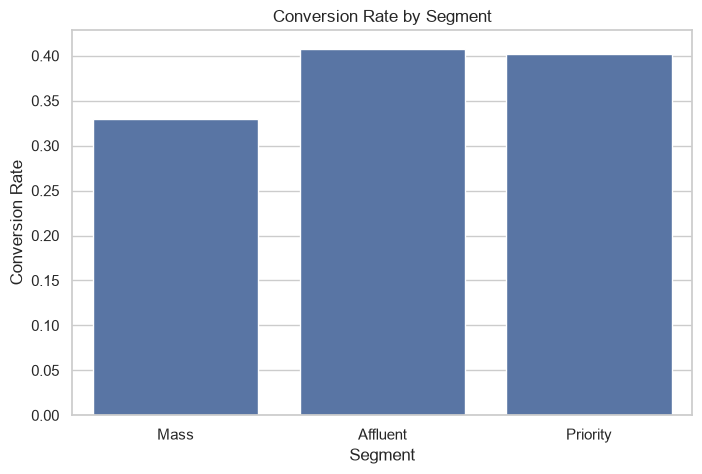

In [4]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Segment",y="Converted",errorbar=None)
plt.title("Conversion Rate by Segment")
plt.ylabel("Conversion Rate")
save_plot("6-explore-conversion.png")
plt.show()

## 7. Define Features and Target

Target:

```text
Converted
```

Features represent information available **before** the sales action.

Avoid leakage.

For example, a feature that records:

```text
Product Activated After Campaign
```

must not be used to rank the lead before the campaign.

In [5]:
target="Converted"

features=[
    "Age",
    "Monthly_Income",
    "Account_Tenure_Months",
    "Product_Count",
    "Monthly_Transactions",
    "Digital_Engagement",
    "Balance",
    "Credit_Utilization",
    "Recent_Application",
    "Segment"
]

X=df[features]
y=df[target]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=.20,
    stratify=y,
    random_state=42
)

print("Train:",X_train.shape)
print("Test:",X_test.shape)

Train: (3200, 10)
Test: (800, 10)


## 8. Build Baseline Conversion Model

A baseline classifier predicts each lead's probability of conversion from the available attributes. The probability — not the binary prediction — is what provides the ranking score.


A simple and interpretable baseline is Logistic Regression.

The model estimates:

```text
P(Convert | Customer Features)
```

We then use this probability as the **ranking score**.

In [6]:
cat_cols=["Segment"]
num_cols=[c for c in features if c not in cat_cols]

preprocessor=ColumnTransformer([
    ("cat",OneHotEncoder(handle_unknown="ignore"),cat_cols),
    ("num",StandardScaler(),num_cols)
])

model=Pipeline([
    ("prep",preprocessor),
    ("model",LogisticRegression(max_iter=1000))
])

model.fit(X_train,y_train)

test_prob=model.predict_proba(X_test)[:,1]

print("ROC-AUC:",round(roc_auc_score(y_test,test_prob),3))
print("Average Precision:",round(
    average_precision_score(y_test,test_prob),3
))

ROC-AUC: 0.607
Average Precision: 0.448


## 9. Why ROC-AUC Is Not Enough

For ranking problems, we care about the **top of the list**.

Suppose:

```text
10,000 leads
```

but sales capacity is:

```text
500 leads
```

The important question becomes:

> How good are the top 500?

Therefore ranking metrics are particularly important.

## 10. Create Ranked Test Set

Test leads are sorted by predicted probability, highest first. This ranked list is the deliverable: agents call the most promising customers first and reach more conversions per hour.


In [7]:
ranked_test=X_test.copy()
ranked_test["Actual_Converted"]=y_test.values
ranked_test["Score"]=test_prob
ranked_test["Lead_ID"]=df.loc[X_test.index,"Lead_ID"].values

ranked_test=ranked_test.sort_values(
    "Score",
    ascending=False
).reset_index(drop=True)

ranked_test["Rank"]=np.arange(1,len(ranked_test)+1)

display(
    ranked_test[
        ["Rank","Lead_ID","Score","Actual_Converted","Segment"]
    ].head(20)
)

,Rank,Lead_ID,Score,Actual_Converted,Segment
0,1,L03987,0.760343,0,Affluent
1,2,L00991,0.747940,0,Affluent
2,3,L02520,0.702808,1,Affluent
3,4,L01625,0.691139,1,Priority
4,5,L00723,0.689552,1,Affluent
5,6,L03034,0.687110,1,Affluent
6,7,L02774,0.684563,1,Mass
7,8,L03627,0.672503,1,Affluent
8,9,L03843,0.659894,0,Affluent
9,10,L01391,0.649235,0,Affluent


## 11. Precision@K

Precision@K answers:

> Among the top K ranked leads, what percentage actually converted?

Example:

```text
Top 100 leads
      ↓
40 converted
      ↓
Precision@100 = 40%
```

This is highly relevant when sales capacity is limited.

In [8]:
def precision_at_k(y_true, scores, k):
    order=np.argsort(-np.asarray(scores))
    top=np.asarray(y_true)[order][:k]
    return top.mean()

for k in [50,100,250,500,1000]:
    print(
        f"Precision@{k}:",
        round(precision_at_k(y_test.values,test_prob,k),3)
    )

Precision@50: 0.48
Precision@100: 0.47
Precision@250: 0.444
Precision@500: 0.414
Precision@1000: 0.36


## 12. Recall@K

Recall@K asks:

> What percentage of all converting leads were captured within the top K?

Formula:

```text
Recall@K
=
Conversions in Top K
/
Total Conversions
```

Precision and recall answer different business questions.

In [9]:
def recall_at_k(y_true,scores,k):
    order=np.argsort(-np.asarray(scores))
    top=np.asarray(y_true)[order][:k]
    return top.sum()/np.asarray(y_true).sum()

for k in [50,100,250,500,1000]:
    print(
        f"Recall@{k}:",
        round(recall_at_k(y_test.values,test_prob,k),3)
    )

Recall@50: 0.083
Recall@100: 0.163
Recall@250: 0.385
Recall@500: 0.719
Recall@1000: 1.0


## 13. Lift@K

Lift compares the conversion rate of the selected top-K group with the overall conversion rate.

```text
Lift@K
=
Precision@K
/
Overall Conversion Rate
```

Example:

```text
Overall conversion = 10%
Top 100 conversion = 30%

Lift@100 = 3.0
```

The top group converts at 3× the overall rate.

In [10]:
overall_rate=y_test.mean()

for k in [50,100,250,500,1000]:
    p_at_k=precision_at_k(y_test.values,test_prob,k)
    lift=p_at_k/overall_rate
    print(f"Lift@{k}:",round(lift,2))

Lift@50: 1.33
Lift@100: 1.31
Lift@250: 1.23
Lift@500: 1.15
Lift@1000: 1.0


## 14. Cumulative Gains

A cumulative gains curve shows how quickly the ranking captures positive outcomes.

Ideal ranking:

```text
Most converters
      ↓
at the top of the list
```

A useful ranking model should capture conversions faster than random selection.

Saved: output/14-cumulative-gains.png


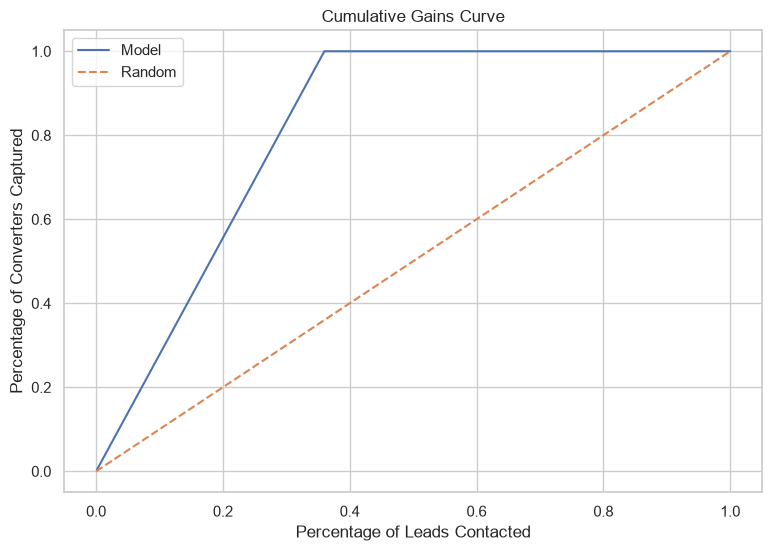

In [11]:
sorted_y=np.sort(y_test.values)[::-1]
cum_gain=np.cumsum(sorted_y)/sorted_y.sum()
population_pct=np.arange(1,len(sorted_y)+1)/len(sorted_y)

fig,ax=plt.subplots(figsize=(9,6))
ax.plot(population_pct,cum_gain,label="Model")
ax.plot([0,1],[0,1],"--",label="Random")
ax.set_title("Cumulative Gains Curve")
ax.set_xlabel("Percentage of Leads Contacted")
ax.set_ylabel("Percentage of Converters Captured")
ax.legend()
save_plot("14-cumulative-gains.png")
plt.show()

## 15. Decile Analysis

Divide ranked leads into 10 groups.

```text
Decile 1 → Highest priority
Decile 10 → Lowest priority
```

This is common in marketing and CRM analytics because it is easy for business users to understand.

In [12]:
ranked_test["Decile"]=pd.qcut(
    ranked_test["Rank"],
    q=10,
    labels=False
)+1

decile_summary=(
    ranked_test.groupby("Decile")
    .agg(
        Leads=("Lead_ID","size"),
        Conversions=("Actual_Converted","sum"),
        Conversion_Rate=("Actual_Converted","mean"),
        Avg_Score=("Score","mean")
    )
    .reset_index()
)

display(decile_summary.round(3))

,Decile,Leads,Conversions,Conversion_Rate,Avg_Score
0,1,80,40,0.500,0.584
1,2,80,37,0.462,0.481
2,3,80,31,0.388,0.435
3,4,80,33,0.412,0.399
4,5,80,36,0.450,0.364
5,6,80,26,0.325,0.334
6,7,80,22,0.275,0.303
7,8,80,25,0.312,0.276
8,9,80,22,0.275,0.242
9,10,80,16,0.200,0.182


Saved: output/15-decile-analysis.png


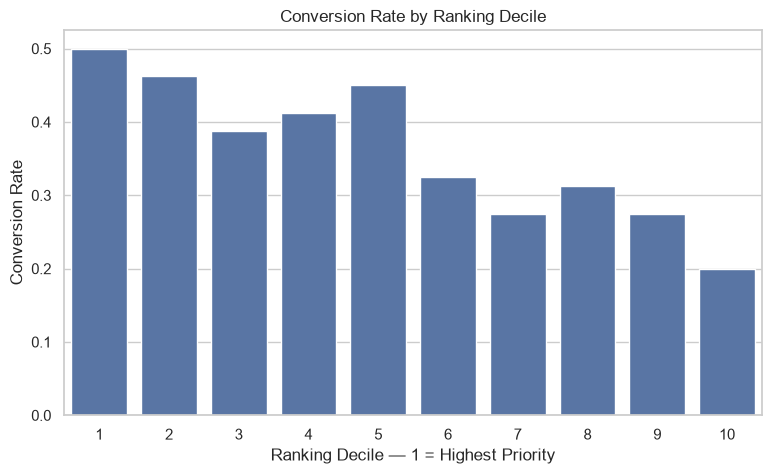

In [13]:
plt.figure(figsize=(9,5))
sns.barplot(
    data=decile_summary,
    x="Decile",
    y="Conversion_Rate"
)
plt.title("Conversion Rate by Ranking Decile")
plt.xlabel("Ranking Decile — 1 = Highest Priority")
plt.ylabel("Conversion Rate")
save_plot("15-decile-analysis.png")
plt.show()

## 16. Top-N Prioritization

Suppose the sales team can contact only:

```text
500 leads
```

We select the first 500 after ranking.

This turns a model score into an operational decision.

In [14]:
TOP_N=500

priority_leads=ranked_test.head(TOP_N).copy()

print("Selected leads:",len(priority_leads))
print("Expected / observed conversion rate:",
      round(priority_leads["Actual_Converted"].mean(),3))

display(
    priority_leads[
        ["Rank","Lead_ID","Score","Segment","Actual_Converted"]
    ].head(20)
)

Selected leads: 500
Expected / observed conversion rate: 0.414


,Rank,Lead_ID,Score,Segment,Actual_Converted
0,1,L03987,0.760343,Affluent,0
1,2,L00991,0.747940,Affluent,0
2,3,L02520,0.702808,Affluent,1
3,4,L01625,0.691139,Priority,1
4,5,L00723,0.689552,Affluent,1
5,6,L03034,0.687110,Affluent,1
6,7,L02774,0.684563,Mass,1
7,8,L03627,0.672503,Affluent,1
8,9,L03843,0.659894,Affluent,0
9,10,L01391,0.649235,Affluent,0


## 17. Ranking Score vs Probability

A probability can be used as a ranking score, but the two concepts are different.

### Probability

Attempts to estimate:

```text
P(Convert)
```

### Ranking Score

Only needs to correctly order:

```text
A > B > C
```

For some ranking applications, a model can be useful even when its probabilities are not perfectly calibrated, as long as the ordering is good.

Calibration should still be checked when probabilities are used for decisions or expected-value calculations.

## 18. Business Value

Suppose:

```text
Sales capacity = 500 leads
Average revenue per conversion = Rp 2,000,000
```

Then a ranking model can prioritize leads with higher estimated conversion likelihood.

A more complete business objective could be:

```text
Expected Value
=
P(Conversion)
× Expected Revenue
− Contact Cost
− Expected Risk / Cost
```

Therefore, **ranking by conversion probability is not always identical to ranking by business value**.

## 19. Multi-Objective Ranking

A mature bank may rank using:

```text
Conversion Probability
        ×
Expected Revenue
        ×
Customer Value
        −
Contact Cost
        −
Risk Penalty
```

This is closer to a true business prioritization score.

The formula should be defined with business stakeholders and validated before deployment.

## 20. Ranking vs Recommendation

Ranking:

> Which existing leads should the sales team prioritize?

Recommendation:

> Which product should this customer be offered?

Example:

```text
Ranking
Customer A → Priority 1
Customer B → Priority 2
Customer C → Priority 3

Recommendation
Customer A → Credit Card
Customer B → Investment
Customer C → Mortgage
```

They can be combined in a Next Best Action system.

## 21. Ranking vs Classification

```text
Classification
       ↓
P(Convert)

Ranking
       ↓
Order leads by P(Convert)
       ↓
Top-N
```

So classification can be the **modeling layer**, while ranking is the **decision layer**.

## 22. Ranking Evaluation Summary

Important metrics:

### Model-level

- ROC-AUC
- PR-AUC / Average Precision

### Ranking-level

- Precision@K
- Recall@K
- Lift@K
- Cumulative Gains
- Decile Analysis

### Business-level

- Conversion
- Revenue
- Profit
- Contact efficiency
- Sales capacity utilization

In [15]:
metrics=[]

for k in [50,100,250,500,1000]:
    p_at_k=precision_at_k(y_test.values,test_prob,k)
    r_at_k=recall_at_k(y_test.values,test_prob,k)
    lift=p_at_k/overall_rate

    metrics.append({
        "K":k,
        "Precision@K":p_at_k,
        "Recall@K":r_at_k,
        "Lift@K":lift
    })

ranking_metrics=pd.DataFrame(metrics)

display(ranking_metrics.round(3))

,K,Precision@K,Recall@K,Lift@K
0,50,0.480,0.083,1.333
1,100,0.470,0.163,1.306
2,250,0.444,0.385,1.233
3,500,0.414,0.719,1.150
4,1000,0.360,1.000,1.000


## 23. Production Architecture

```text
Bank Data Warehouse
        ↓
Feature Engineering
        ↓
Lead Scoring Model
        ↓
Ranking Engine
        ↓
Eligibility / Compliance
        ↓
Top-N Leads
        ↓
CRM / Sales
        ↓
Customer Response
        ↓
Outcome Tracking
        ↓
Model Monitoring
```

For real-time use, the scoring service can be exposed through an API.

For batch sales campaigns, ranking can be generated daily.

## 24. Governance and Fairness

Ranking systems can influence who receives sales attention.

Therefore monitor:

- sensitive-feature usage,
- segment disparities,
- approval / eligibility constraints,
- unwanted targeting,
- customer complaints,
- campaign fatigue,
- data leakage,
- model drift.

A high ranking score should not override regulatory or bank policy constraints.

## 25. Common Mistakes

1. Optimizing only ROC-AUC.
2. Ignoring Top-K performance.
3. Ranking by probability without checking calibration when probability matters.
4. Data leakage from post-contact variables.
5. Ignoring sales capacity.
6. Optimizing conversion while ignoring revenue or cost.
7. Using arbitrary thresholds.
8. Not validating rankings on future periods.
9. Ignoring customer suitability and eligibility.
10. Not monitoring ranking drift.

## 26. Temporal Validation

For production ranking, use time-based validation where possible.

Example:

```text
Jan–Sep → Training
Oct      → Validation
Nov–Dec  → Test
```

This better reflects the real business process:

```text
Train on the past
Rank future leads
Observe future outcomes
```

Random splitting can sometimes produce overly optimistic results when customer behavior changes over time.

## 27. Final Executive Summary

### Business Question

> **Which leads or customers should the bank prioritize?**

### Solution

```text
Customer Data
      ↓
Conversion Model
      ↓
Probability / Score
      ↓
Ranking
      ↓
Top-K
      ↓
Sales Prioritization
```

### Key Metrics

```text
Precision@K
Recall@K
Lift@K
Cumulative Gains
Decile Conversion
```

### Main Takeaway

> **Ranking converts predictive scores into an ordered list that can be matched to limited business capacity.**

For banking, this is useful when the bank has **more potential customers than sales or relationship-manager capacity**.

## 28. Save Outputs

All key result tables and figures are saved into the local `output/` folder, so results survive after the kernel is restarted and can be shared without re-running the notebook.


In [16]:
ranked_test.to_csv(OUTPUT_DIR / "ranked_leads_test_set.csv", index=False)
print("Saved:", OUTPUT_DIR / "ranked_leads_test_set.csv")
decile_summary.to_csv(OUTPUT_DIR / "decile_conversion_analysis.csv", index=False)
print("Saved:", OUTPUT_DIR / "decile_conversion_analysis.csv")


# List everything that was written to output/
for _p in sorted(OUTPUT_DIR.iterdir()):
    print(" ", _p)


Saved: output/ranked_leads_test_set.csv
Saved: output/decile_conversion_analysis.csv
  output/14-cumulative-gains.png
  output/15-decile-analysis.png
  output/6-explore-conversion.png
  output/decile_conversion_analysis.csv
  output/ranked_leads_test_set.csv
